In [1]:
!pip install -q kagglehub

In [2]:
from google.colab import files
import os
import kagglehub

# Step 1: Upload kaggle.json manually
print("📂 Please upload your kaggle.json file:")
uploaded = files.upload()

# Ensure the uploaded file exists
if "kaggle.json" not in uploaded:
    print("❌ kaggle.json upload failed. Please try again.")
else:
    # Step 2: Move the file to the correct location
    !mkdir -p /root/.config/kaggle
    !mv kaggle.json /root/.config/kaggle/

    # Step 3: Set proper permissions (read and write)
    !chmod 600 /root/.config/kaggle/kaggle.json

    # Step 4: Verify that the file exists
    if os.path.exists("/root/.config/kaggle/kaggle.json"):
        print("✅ kaggle.json uploaded and set up correctly!")
    else:
        print("❌ kaggle.json upload failed. Please check the file path.")

# Step 5: download dataset
try:
    dataset_path = kagglehub.dataset_download("moazeldsokyx/dogs-vs-cats")
    print("✅ Dataset downloaded successfully!")
    print("📂 Path to dataset files:", dataset_path)

    # Step 7: Move dataset to /content/{dataset-name} for easier access
    target_path = os.path.join(os.getcwd(), "dataset")
    !mkdir -p {target_path}  # Ensure target directory exists
    !cp -r {dataset_path}/* {target_path}/

    print(f"✅ Dataset moved to {target_path}")
    print("📂 Final Dataset contents:", os.listdir(target_path))

except Exception as e:
    print("❌ Error downloading dataset:", e)

📂 Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
✅ kaggle.json uploaded and set up correctly!
Using Colab cache for faster access to the 'dogs-vs-cats' dataset.
✅ Dataset downloaded successfully!
📂 Path to dataset files: /kaggle/input/dogs-vs-cats
✅ Dataset moved to /content/dataset
📂 Final Dataset contents: ['dataset']


In [3]:
import os

In [4]:
DATASET_FOLDER_PATH = os.path.join(os.getcwd(), "dataset/dataset")
TRAIN_FOLDER_PATH = os.path.join(DATASET_FOLDER_PATH, "train")
TEST_FOLDER_PATH = os.path.join(DATASET_FOLDER_PATH, "test")
VALIDATION_FOLDER_PATH = os.path.join(DATASET_FOLDER_PATH,'validation')
DESTINATION_FOLDER_PATH = os.path.join(os.getcwd(), "subset_dataset")

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import glob

In [6]:
sizes = []
images_pack = []

for folder in os.listdir(TRAIN_FOLDER_PATH):
  images = glob.glob(pathname = str(TRAIN_FOLDER_PATH + '/' + folder + '/*.jpg'))
  print(folder)
  images_pack.append(images)
  for image in images:
    image = plt.imread(image)
    sizes.append(image.shape)

pd.Series(sizes).value_counts().head()



cats
dogs


,count
"(374, 500, 3)",2365
"(375, 499, 3)",2300
"(499, 375, 3)",206
"(500, 374, 3)",191
"(333, 499, 3)",183


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
_,dogs,_,cats = train_test_split(images_pack[1],images_pack[0],test_size=0.1,random_state=42,shuffle=True)
dogs_train , dogs_validation = train_test_split(dogs,test_size=0.5,random_state=42,shuffle=True)
dogs_validation , dogs_test = train_test_split(dogs_validation,test_size=0.5,random_state=42,shuffle=True)
cats_train , cats_validation = train_test_split(cats,test_size=0.5,random_state=42,shuffle=True)
cats_validation,cats_test = train_test_split(cats_validation,test_size=0.5,random_state=42,shuffle=True)

In [9]:
len(dogs_train),len(dogs_validation),len(dogs_test) , len(cats_train),len(cats_validation),len(cats_test)

(500, 250, 250, 500, 250, 250)

In [10]:
import shutil

In [11]:

TRAIN_DIR = os.path.join(DESTINATION_FOLDER_PATH,'train')
TEST_DIR = os.path.join(DESTINATION_FOLDER_PATH,'test')
VALIDATION_DIR = os.path.join(DESTINATION_FOLDER_PATH,'validation')

TRAIN_CATS_DIR = os.path.join(TRAIN_DIR,'cats')
TRAIN_DOGS_DIR = os.path.join(TRAIN_DIR,'dogs')

VALID_DOGS_DIR = os.path.join(VALIDATION_DIR,'dogs')
VALID_CATS_DIR = os.path.join(VALIDATION_DIR,'cats')

TEST_DOGS_DIR = os.path.join(TEST_DIR,'dogs')
TEST_CATS_DIR = os.path.join(TEST_DIR,'cats')

os.makedirs(TRAIN_DIR,exist_ok=True)
os.makedirs(TEST_DIR,exist_ok=True)
os.makedirs(VALIDATION_DIR,exist_ok=True)

os.makedirs(TRAIN_CATS_DIR,exist_ok=True)
os.makedirs(TRAIN_DOGS_DIR,exist_ok=True)

os.makedirs(VALID_DOGS_DIR,exist_ok=True)
os.makedirs(VALID_CATS_DIR,exist_ok=True)

os.makedirs(TEST_DOGS_DIR,exist_ok=True)
os.makedirs(TEST_CATS_DIR,exist_ok=True)



In [12]:
for dog in dogs_train:
  shutil.copy(dog,TRAIN_DOGS_DIR)
for cat in cats_train:
  shutil.copy(cat,TRAIN_CATS_DIR)
for dog in dogs_validation:
  shutil.copy(dog,VALID_DOGS_DIR)
for cat in cats_validation:
  shutil.copy(cat,VALID_CATS_DIR)
for dog in dogs_test:
  shutil.copy(dog,TEST_DOGS_DIR)
for cat in cats_test:
  shutil.copy(cat,TEST_CATS_DIR)

In [13]:
print("Training dataset:-")
for folder in os.listdir(TRAIN_DIR):
  print(folder,len(os.listdir(os.path.join(TRAIN_DIR,folder))))

print("Validation dataset:-")
for folder in os.listdir(VALIDATION_DIR):
  print(folder,len(os.listdir(os.path.join(VALIDATION_DIR,folder))))

print("Test dataset:-")
for folder in os.listdir(TEST_DIR):
  print(folder,len(os.listdir(os.path.join(TEST_DIR,folder))))

Training dataset:-
cats 500
dogs 500
Validation dataset:-
cats 250
dogs 250
Test dataset:-
cats 250
dogs 250


In [14]:
#shutil.rmtree(os.path.join(os.getcwd(),'dataset'))

image shape : (374, 500, 3)
maximum pixel value : 255
minimum pixel value : 0


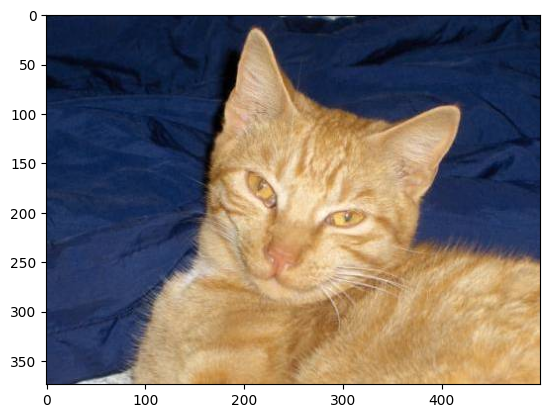

In [15]:
for img in os.listdir(TRAIN_CATS_DIR):
  x=plt.imread(os.path.join(TRAIN_CATS_DIR,img))
  plt.imshow(x)
  print(f"image shape : {x.shape}")
  print(f"maximum pixel value : {x.max()}")
  print(f"minimum pixel value : {x.min()}")
  break


In [16]:
import tensorflow as tf
import pandas as pd
import numpy as np

In [17]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(150,150,3)
)
base_model.trainable = False
base_model.trainable

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


False

In [18]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 150, 150,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 150, 150,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 150, 150,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 151, 151,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 75, 75,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 75, 75,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 75, 75,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 75, 75,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 75, 75,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 75, 75,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 75, 75,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 75, 75,    │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [19]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function =tf.keras.applications.efficientnet.preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

other_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

valid_gen = other_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

test_gen = other_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 1000 images belonging to 2 classes.
Found 500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [20]:
# Model
inputs = tf.keras.layers.Input(shape=(150,150,3),name='input_layer')
x = base_model(inputs,training = False)
x = tf.keras.layers.GlobalAveragePooling2D(name='global_average_pooling_layer')(x)
x = tf.keras.layers.Dense(128,activation ='relu')(x)
x=tf.keras.layers.Dropout(0.5)(x)
outputs=tf.keras.layers.Dense(1,activation='sigmoid',name='output_layer')(x)

model = tf.keras.Model(inputs,outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [21]:
from operator import le
# Compiling and training
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy', metrics=['accuracy'])

earlystop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                             patience=5,restore_best_weights = True)

reduceonplateu = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3)

history = model.fit(train_gen,validation_data=valid_gen, epochs=20)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.6345 - loss: 0.6256 - val_accuracy: 0.9480 - val_loss: 0.3753
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 238ms/step - accuracy: 0.8836 - loss: 0.3810 - val_accuracy: 0.9620 - val_loss: 0.2427
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 233ms/step - accuracy: 0.9313 - loss: 0.2723 - val_accuracy: 0.9700 - val_loss: 0.1775
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 210ms/step - accuracy: 0.9228 - loss: 0.2306 - val_accuracy: 0.9800 - val_loss: 0.1432
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 244ms/step - accuracy: 0.9394 - loss: 0.1856 - val_accuracy: 0.9800 - val_loss: 0.1227
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 210ms/step - accuracy: 0.9470 - loss: 0.1599 - val_accuracy: 0.9780 - val_loss: 0.1091
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 242ms/step - accuracy: 0.9550 - loss: 0.1344 - val_accuracy: 0.9780 - val_loss: 0.0985
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 233ms/step - accuracy: 0.9515 - loss: 0.1524 - val_accuracy: 0.97

In [30]:
ASSEST_FOLDER_PATH = os.path.join(os.getcwd(),'assets')
os.makedirs(ASSEST_FOLDER_PATH,exist_ok=True)
model.save(os.path.join(ASSEST_FOLDER_PATH,'model.keras'))

idx2label = {v:k for k,v in train_gen.class_indices.items()}
idx2label

{0: 'cats', 1: 'dogs'}

In [32]:
import joblib
joblib.dump(idx2label,os.path.join(ASSEST_FOLDER_PATH,'idx2label.joblib'))


['/content/assets/idx2label.joblib']